# 5.11 A Taste of Non-Equilibrium: Irreversibility, the Arrow of Time, and the Approach to Equilibrium

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume V — Classical Statistical Mechanics",
    number="5.11",
    title="A Taste of Non-Equilibrium: Irreversibility, the Arrow of Time, and the Approach to Equilibrium",
    blurb="The question every ensemble quietly assumed. Microscopic dynamics "
    "runs equally well backwards and returns to its start, yet a gas spreads, "
    "heat flows, and entropy rises — once. We watch irreversibility emerge from "
    "reversible rules in a ring of flipping balls, see a gas find the "
    "Maxwell–Boltzmann law, and meet Brownian motion and the Einstein relation. "
    "This is a glimpse through a door into a subject of its own; we open it just "
    "wide enough to see in.",
    difficulty="advanced",
    estimate="220–260 min",
)

<ECP header: 2805 chars of HTML>

## Notebook overview

A frank word at the outset, because this notebook is unlike the others. It is the longest and most
demanding of the volume, and deliberately so — and it is, we think, among the most rewarding of the
whole series. The reason is honest scope: non-equilibrium statistical mechanics is genuinely a
subject of its own, several courses' worth, and we do not attempt a survey. We attempt a single
coherent **taste**. The title word is load-bearing. We will follow *one* thread — irreversibility,
the arrow of time — as far as a notebook can honestly take it, and we will name the rest of the
field's great landmarks as **horizons**, pointing through the door without pretending to walk the
whole room. Modelling that honesty, about what one sitting can and cannot do, is part of the lesson.

The thread answers a question the entire volume quietly assumed and never asked. Every ensemble we
built — microcanonical, canonical, grand canonical — *described* equilibrium: where a system ends
up. None asked *why* it goes there. And the puzzle, once you see it, is sharp. The microscopic
dynamics is **time-reversible** (Hamilton's equations run backwards just as well; Liouville's
theorem of [§5.5](ergodicity.ipynb)) and **recurrent** (Poincaré: a bounded system returns arbitrarily close to any past
state). Yet a gas released in a corner spreads to fill its box and never spontaneously gathers back;
heat flows from hot to cold and not the reverse; entropy rises in *one* direction. How can a
temporal asymmetry — an arrow of time — emerge from laws that have none?

The resolution, which we will *show* rather than assert, is that irreversibility is **emergent and
probabilistic**. It is not in the microscopic laws; it appears when we coarse-grain and count. The
**Kac ring** makes this exactly computable: a deterministic, reversible, periodic toy in which a
coarse-grained quantity nonetheless relaxes monotonically — Loschmidt's reversal and Zermelo's
recurrence objections to Boltzmann, made concrete and answered in a single model. A gas of colliding
particles then shows **Boltzmann's H-theorem** in action, relaxing irreversibly to the very
Maxwell–Boltzmann law of [§5.6](ideal-gas-fundamental-relation.ipynb). And the deep reason is the one that has run through the whole volume:
the equilibrium macrostate is *overwhelmingly* the most probable (the $1/\sqrt N$ concentration of
[§5.3](large-n-limit.ipynb)), so a system started elsewhere almost certainly moves toward it, while the reversed,
entropy-decreasing trajectories — which genuinely exist — are vanishingly rare, and the recurrence
times, though real, are longer than the age of the universe by unimaginable factors.

We end with a first taste of **transport** — Brownian motion, the Langevin equation, and the
Green–Kubo relation — which is the *dynamical* face of the fluctuation–response idea of [§5.9](grand-canonical-ensemble-equivalence.ipynb). There,
[§5.9](grand-canonical-ensemble-equivalence.ipynb) told us a response function is a static fluctuation; here a transport coefficient turns out to be
an equilibrium *time* correlation, and the Einstein relation $D=kT/\gamma$ ties diffusion to friction
as two faces of the same molecular collisions. The loop closes: the non-equilibrium dynamics relaxes
to exactly the Boltzmann equilibrium the rest of the volume described. We began the volume by
counting microstates; we end it by watching the arrow of time turn out to be a count.

> **How to read the checks.** Each exercise closes with a `validate` call against an independent
> fact: a reversible trajectory retracing itself; the Kac ring relaxing as $(1-2\mu)^t$ and then
> *recurring* exactly at $t=2N$; the Maxwell–Boltzmann distribution minimizing $H$; a gas relaxing
> to it with $H$ monotone; equilibrium's overwhelming probability and astronomical recurrence; free
> Brownian motion with $\langle x^2\rangle=2Dt$ and $D=kT/\gamma$; the velocity autocorrelation
> integrating (Green–Kubo) to that same $D$; and a trapped particle relaxing to $\langle x^2\rangle
> =kT/k$. A ✓ is strong evidence; a ✗ is a prompt to *locate the discrepancy*.
>
> **Scope — a taste, and the horizons.** One thread (irreversibility) is developed in full; the rest
> of non-equilibrium statistical mechanics is *named, not derived* — the full Boltzmann transport
> equation, the Green–Kubo relations for viscosity and conductivity, Onsager reciprocity, linear
> response and the dynamical fluctuation–dissipation theorem, the Fokker–Planck and master equations,
> hydrodynamics, and the modern fluctuation theorems (Jarzynski, Crooks). The production craft of
> stochastic simulation belongs to molecular-simulation courses and MMM. See Kac (1959); Kardar,
> *Statistical Physics of Particles*; Chandler; Zwanzig, *Nonequilibrium Statistical Mechanics*; and
> Notebooks [§5.5](ergodicity.ipynb) (Liouville, reversibility), [§5.6](ideal-gas-fundamental-relation.ipynb) (Maxwell–Boltzmann), [§5.3](large-n-limit.ipynb) ($1/\sqrt N$), [§5.4](microstates-entropy-temperature.ipynb) (the
> Boltzmann equilibrium), [§5.9](grand-canonical-ensemble-equivalence.ipynb) (fluctuation–response).

## Theory in brief

### The puzzle: irreversibility from reversible laws

The microscopic dynamics is **time-reversible** and **recurrent**,

```{math}
:label: eq-puzzle
\text{reverse all velocities} \Rightarrow \text{the system retraces its path};\qquad
\text{Poincaré: it returns arbitrarily close to any past state,}
```

yet macroscopic systems approach equilibrium irreversibly and entropy rises in one direction. How a
temporal asymmetry emerges from time-symmetric laws is the founding question of non-equilibrium
statistical mechanics — the one the equilibrium theory of [§5.4](microstates-entropy-temperature.ipynb)–[§5.10](ising-emergence-universality.ipynb) never asked.

### The Kac ring: irreversibility made exactly computable

$N$ balls (black or white) sit on a ring; **stationary** markers occupy a fraction $\mu$ of the
edges. Each step every ball steps one site and flips colour iff it crosses a marker. The dynamics is
deterministic, **reversible**, and **periodic** (period $2N$: after two circuits every marker is
crossed twice, restoring every colour — Poincaré recurrence, exactly). Yet under the
**molecular-chaos** assumption (treat the markers a ball is about to meet as a random fraction
$\mu$), the order parameter $\Delta=\frac1N\sum_i\sigma_i$ relaxes monotonically,

```{math}
:label: eq-kac
\Delta(t)=(1-2\mu)^t\,\Delta(0)\ \to\ 0\ \text{(relaxation)},\qquad \Delta(2N)=\Delta(0)\ \text{(recurrence)} .
```

The same model shows *irreversible* relaxation (coarse-grained, probabilistic) and *exact*
reversibility/recurrence — Loschmidt and Zermelo, answered: irreversibility is emergent and
approximate, not fundamental.

### The Boltzmann equation and the H-theorem

Boltzmann's kinetic equation evolves a gas's velocity distribution $f(\mathbf v,t)$ under collisions.
Its decisive input is the **Stoßzahlansatz** (molecular chaos): colliding particles are *uncorrelated
before* they collide. That assumption — not the microscopic dynamics — breaks time-reversal symmetry,
and from it follows the **H-theorem**,

```{math}
:label: eq-htheorem
H=\int f\ln f\,d\mathbf v\ \text{ decreases monotonically until } f=f_{\rm MB},
```

the entropy $-kH$ rising to its maximum at the unique stationary state, Maxwell–Boltzmann. The full
collision integral and transport equation are *named, not derived* (a horizon).

### Relaxation to Maxwell–Boltzmann

We demonstrate the H-theorem with a caricature of the Boltzmann equation: repeated random binary
collisions that conserve momentum and energy (rotate each colliding pair's relative velocity by a
random angle — molecular chaos made literal). From a non-equilibrium start the speed distribution
relaxes to the two-dimensional **Maxwell–Boltzmann** law ([§5.6](ideal-gas-fundamental-relation.ipynb)),

```{math}
:label: eq-relaxation
f(v)=\frac{m}{kT}\,v\,e^{-mv^2/2kT},\qquad H\ \text{monotone decreasing,}
```

and the equilibrium it finds is exactly the Boltzmann distribution of [§5.4](microstates-entropy-temperature.ipynb)/[§5.6](ideal-gas-fundamental-relation.ipynb).

### The resolution of the paradoxes

Irreversibility does not contradict reversibility; it emerges from **coarse-graining + overwhelming
probability**,

```{math}
:label: eq-resolution
\frac{\#\,\text{equilibrium microstates}}{\#\,\text{all microstates}}\to1,\qquad t_{\rm recurrence}\sim e^{O(N)} .
```

The equilibrium macrostate occupies almost all of phase space (the $1/\sqrt N$ concentration of [§5.3](large-n-limit.ipynb)),
so a system almost certainly moves toward it; reversed trajectories exist but are vanishingly rare,
and recurrence times, though real, are astronomically long. The arrow of time is the statistics of
large numbers applied to dynamics.

### A taste of transport: Brownian motion and Green–Kubo

A heavy particle in a fluid obeys the **Langevin** equation $m\,\dot v=-\gamma v+\xi(t)$ with
$\langle\xi(t)\xi(t')\rangle=2\gamma kT\,\delta(t-t')$ — friction and noise are two faces of the same
collisions (Einstein 1905). Free Brownian motion diffuses, $\langle x^2\rangle=2Dt$, with the
**Einstein relation** $D=kT/\gamma$. The velocity **autocorrelation function**
$C(t)=\langle v(0)v(t)\rangle$ — how long a fluctuating quantity remembers itself — and the
**Green–Kubo** relation give the transport coefficient as its time integral,

```{math}
:label: eq-transport
C(t)=\frac{kT}{m}e^{-(\gamma/m)t},\qquad D=\int_0^\infty\!\langle v(0)v(t)\rangle\,dt=\frac{kT}{\gamma} .
```

Transport coefficients *are* equilibrium time-correlation functions — the **dynamical**
fluctuation–dissipation theorem, the time-resolved extension of the static response = fluctuation of [§5.9](grand-canonical-ensemble-equivalence.ipynb).

### The horizons

What this one notebook only peeked at, each a pointer and none developed: the full **Boltzmann
transport equation** and kinetic theory; the **Green–Kubo** relations for viscosity and thermal
conductivity; **Onsager**'s reciprocal relations; **linear response** and the dynamical
fluctuation–dissipation theorem in full; the **Fokker–Planck** and master equations; hydrodynamics;
and the modern **fluctuation theorems** (Jarzynski's $\langle e^{-\beta W}\rangle=e^{-\beta\Delta F}$,
Crooks) relating non-equilibrium work to equilibrium free energy. Non-equilibrium
statistical mechanics is a subject of its own; this was a taste.

## Setup

The data are the series palette, a red for the ring's flip markers, and the unit convention
$k_B=1$ (masses, frictions and temperatures are stated per exercise). The one instrument is
`H_functional`, the histogram meter that reads Boltzmann's $H$ off a sample of speeds: it fixes
the grid so that every distribution in Exercise 4 and every frame of the relaxation in Exercise
5 is measured on the same scale, which is bookkeeping rather than physics. Every *dynamics*
this notebook runs is one of its lessons and is built where it is earned — the reversible
velocity-Verlet integrator in Exercise 1, the Kac ring in Exercise 2, the energy-conserving
collision update in Exercise 5, the BAOAB Langevin integrator in Exercise 7, and the velocity
autocorrelation in Exercise 8. Each exercise seeds its own generator where randomness enters.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

from ecp import draw, validate
from ecp.animate import show

# data: the series palette, plus a red for the Kac ring's flip markers
ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT
RED = "#c1121f"

# data: units throughout. k_B = 1. Masses, frictions, temperatures stated per exercise.


# instrument: a meter, not a lesson. What Exercises 4 and 5 put under test is which distribution
# minimizes H and that a relaxing gas drives it downhill — not how a sample is binned. The grid is
# fixed here once so every distribution and every frame is measured on the same scale.
def H_functional(speeds, bins=30, v_max=3.5):
    """Boltzmann's H = ∫ f ln f dv, estimated from a speed sample by histogram (`numpy.histogram`).

    Forms the normalized speed density f on a fixed grid and returns Σ_i f_i ln f_i Δv
    over the occupied bins — the discretized ∫ f ln f. The H-theorem says this decreases as a
    gas relaxes, reaching its minimum at the Maxwell–Boltzmann distribution.

    Parameters
    ----------
    speeds : numpy.ndarray
        Particle speeds.
    bins : int, optional
        Number of histogram bins (default ``30``).
    v_max : float, optional
        Upper edge of the speed grid (default ``3.5``).

    Returns
    -------
    float
        The estimated H.
    """
    f, edges = np.histogram(speeds, bins=bins, range=(0.0, v_max), density=True)
    dv = edges[1] - edges[0]
    nz = f > 0
    return float(np.sum(f[nz] * np.log(f[nz])) * dv)

## Exercise 1 — The puzzle of the arrow of time (worked)

We begin by sharpening the paradox until it is undeniable. The microscopic laws of motion have no
preferred direction of time: run Hamilton's equations backwards and they are still Hamilton's
equations, and Liouville's theorem of [§5.5](ergodicity.ipynb) says the flow conserves phase-space volume in either
direction. We can see the reversibility directly. Take a particle in some potential, integrate its
motion with a time-symmetric (velocity-Verlet) scheme, then *reverse its velocity* and integrate
again — it retraces its path exactly, arriving back where it started {eq}`eq-puzzle`
({numref}`fig-ne-puzzle`). And the dynamics is recurrent: Poincaré proved that a bounded system
returns arbitrarily close to any earlier state, given enough time. So at the level of the molecules,
nothing distinguishes forward from backward, and nothing is lost forever. Yet the world we see is
emphatically one-directional — gases spread, cream mixes into coffee, things cool, and never the
reverse. The whole equilibrium theory of this volume described the destination without ever asking
why the journey runs only one way. That question is the subject of this notebook.

The specimen is a single particle under the anharmonic restoring force $F(x)=-x-0.3x^3$, whose
cubic stiffening keeps the motion from being a special integrable case, started at $x=1.5$ with
$v=0.4$ and integrated with timestep $\Delta t=0.01$. Velocity Verlet is the scheme to use
because it is *time-symmetric*: one step advances $x\to x+v\Delta t+\tfrac12a\Delta t^2$,
recomputes the acceleration at the new position, and then advances
$v\to v+\tfrac12(a_{\rm old}+a_{\rm new})\Delta t$, and running that step with the velocity
reversed undoes it exactly. Reversibility is therefore a property of the integrator as much as
of the physics, and a scheme without it would blur the very point being made.

**Part a)** Write `verlet(x, v, force, dt, n_steps, m=1.0)`, taking one velocity-Verlet step at
a time and returning the final position, the final velocity, and the array of positions visited.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Integrate $2000$ steps forward from $(x,v)=(1.5,0.4)$, then reverse the velocity and
integrate $2000$ steps again, and confirm the particle returns to its exact starting point
(`atol=1e-6`) — the microscopic dynamics is time-reversible.

In [3]:
# (solution hidden on the public site)


the microscopic dynamics is time-reversible:
  start:                       x = 1.5, v = 0.4
  after forward + velocity-reversed: x = 1.500000, v = 0.400000
  returned to the start: True
yet macroscopic systems never run backwards — that is the puzzle


### Validation 1

In [4]:
validate.close(
    [x_back, -v_back],
    [x_start, v_start],
    "reversing the velocities retraces the trajectory exactly — the microscopic dynamics is time-reversible (yet macroscopic behavior is not)",
    atol=1e-6,
)

✓  reversing the velocities retraces the trajectory exactly — the microscopic dynamics is time-reversible (yet macroscopic behavior is not)   [max|Δ| = 8.77076e-15 (rtol=1e-06, atol=1e-06)]


True

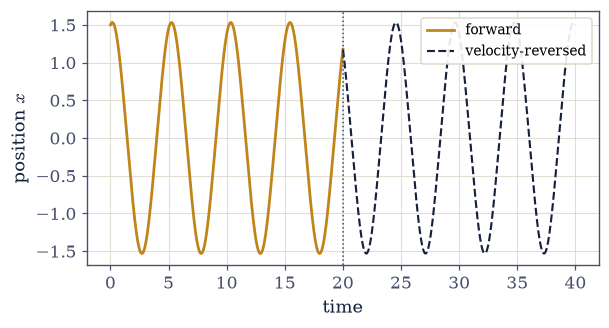

In [5]:
# (solution hidden on the public site)


## Exercise 2 — The Kac ring I: irreversible relaxation under molecular chaos (worked)

To resolve the puzzle we need a model simple enough to understand completely and rich enough to show
the paradox, and Mark Kac's ring (1959) is the perfect one. Picture $N$ balls on a ring of $N$ sites,
each ball black or white, and fix **markers** on some fraction $\mu$ of the edges between sites
({numref}`fig-ne-kac-ring`). The rule: at every step each ball advances one site, and it flips
colour if and only if it crosses a marker. The markers never move; only the balls circulate. This
dynamics is utterly deterministic and, as we will see in Exercise 3, exactly reversible and periodic
— there is no randomness and no friction anywhere in it. And yet watch the order parameter
$\Delta=\frac1N\sum_i\sigma_i$ (the excess of one colour). If we make the **molecular-chaos
assumption** — that the markers a ball is about to encounter are a *random* fraction $\mu$ of the
edges ahead, uncorrelated with its history — then each step a fraction $\mu$ of balls flip, and a
short calculation gives monotonic, irreversible relaxation, $\Delta(t)=(1-2\mu)^t\Delta(0)\to0$
{eq}`eq-kac`. The coarse-grained quantity decays to equilibrium exactly as the H-theorem will have a
gas do — and from a perfectly reversible rule.

Coding the ring is three lines and one trap. Represent the balls as $\sigma_i=\pm1$ and the
edges as $\eta_i=\pm1$, with $\eta_i=-1$ on the fraction $\mu$ of edges that carry a marker;
then one step of the whole ring is $\sigma\leftarrow\eta\cdot\mathrm{roll}(\sigma,1)$, a
circulation by one site (`numpy.roll`) followed by a flip wherever a marker was crossed. The
trap is that the markers are placed *once* and never move again — it is the balls that
circulate past them, and a version that rolls the markers too is a different (and unremarkable)
model. The run below uses $N=4000$ balls and $\mu=0.12$: the molecular-chaos prediction is
exact only as $N\to\infty$, so a large ring keeps the early agreement tight, and the first
eight steps are the window where the markers ahead of a ball really are uncorrelated with its
history.

**Part a)** Write `kac_ring(N, mu, n_steps, rng)`, which starts every ball white
($\sigma_i=+1$, so $\Delta(0)=1$), places the markers once with `rng`, and returns the
order-parameter trace $\Delta(t)=\frac1N\sum_i\sigma_i$ of length `n_steps + 1`.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Run it for $2N$ steps and confirm the early relaxation matches the molecular-chaos
prediction $(1-2\mu)^t$ over the first eight steps (`atol=5e-2`), and that $\Delta$ then sits
near zero.

In [6]:
# (solution hidden on the public site)


Kac ring: N = 4000 balls, μ = 0.12 (fraction of marked edges)
  early relaxation vs molecular-chaos (1−2μ)^t:
    Δ(1) = +0.7535   (1−2μ)^t = +0.7600
    Δ(3) = +0.4575   (1−2μ)^t = +0.4390
    Δ(5) = +0.2795   (1−2μ)^t = +0.2536
  Δ falls toward 0: typical |Δ| in the relaxed window ≈ 0.0248


### Validation 2

In [7]:
validate.close(
    delta[:8],
    mc_prediction,
    "under molecular chaos the Kac-ring order parameter relaxes as (1−2μ)^t — irreversible decay from a reversible rule",
    atol=5e-2,
)

✓  under molecular chaos the Kac-ring order parameter relaxes as (1−2μ)^t — irreversible decay from a reversible rule   [max|Δ| = 0.0273782 (rtol=1e-06, atol=0.05)]


True

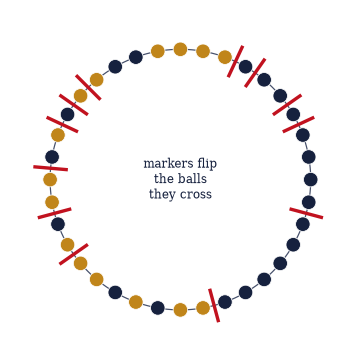

In [8]:
# (solution hidden on the public site)


## Exercise 3 — The Kac ring II: reversibility, recurrence, and the paradoxes resolved (worked)

Now we spring the trap that caught Boltzmann's critics, and disarm it. Boltzmann claimed his gas
relaxes irreversibly to equilibrium; two objections followed. **Loschmidt** (the reversal paradox):
the laws are time-symmetric, so for every relaxing trajectory there is a reversed one in which
entropy *decreases* — how can relaxation be universal? **Zermelo** (the recurrence paradox):
Poincaré says a bounded system returns to its start, so entropy cannot rise forever. The Kac ring
settles both, because we can compute its *exact* dynamics, not just the molecular-chaos
approximation. Run the ring out to $t=2N$ and the order parameter $\Delta$ snaps **exactly** back to
$\Delta(0)$ ({numref}`fig-ne-kac-relax`): after two full circuits every ball has crossed every marker
exactly twice, two flips cancel, and the original configuration is restored, period $2N$
{eq}`eq-kac`. And the dynamics is reversible — reverse the stepping and it retraces. So both
objections are *correct*: the exact dynamics is reversible and recurrent. They simply do not
contradict the relaxation, because the smooth $(1-2\mu)^t$ decay was never the exact dynamics — it was
the molecular-chaos *approximation*, which holds early (when the markers ahead really are
uncorrelated with a ball's history) and breaks down long before the recurrence. Irreversibility is
emergent and approximate, exact at neither the shortest nor the recurrence timescale. Loschmidt and
Zermelo, answered in one model.

The trace already computed in Exercise 2 ran to $t=2N$, so both recurrences are in it and
nothing new needs simulating. Two entries tell the story: the half-period value $\Delta(N)$,
where every ball has crossed every marker exactly once and the sign of $\Delta$ is simply
flipped for a ring with an odd number of markers, and the full-period value $\Delta(2N)$, where
every marker has been crossed twice and the two flips cancel. Neither is approximate, which is
why the check below can demand a relative tolerance of $10^{-9}$ rather than the loose
tolerance a statistical claim would need.

**Part a)** From the $\Delta(t)$ trace of the `kac_ring` you wrote in Exercise 2, read off
$\Delta(0)$, the half-period value $\Delta(N)$, and the full-period value $\Delta(2N)$.

**Part b)** Confirm $\Delta(2N)=\Delta(0)$ to `rtol=1e-9` — exact Poincaré recurrence, with the
molecular-chaos curve of Exercise 2 having tracked only the early relaxation.

In [9]:
# (solution hidden on the public site)


Kac ring exact dynamics (N = 4000):
  Δ(0)  = +1.0000
  Δ(N)  = -1.0000   (half-period recurrence (-1)^m Δ(0) = ±1, not chaos's ≈0)
  Δ(2N) = +1.0000   ← exact recurrence to Δ(0) (Poincaré/Zermelo, period 2N)
the smooth (1−2μ)^t decay was the molecular-chaos approximation, not the reversible exact dynamics


### Validation 3

In [10]:
validate.close(
    recurrence_delta,
    delta[0],
    "the exact Kac-ring dynamics recurs at t=2N (Poincaré) — reversible and recurrent underneath the irreversible relaxation",
    rtol=1e-9,
)

✓  the exact Kac-ring dynamics recurs at t=2N (Poincaré) — reversible and recurrent underneath the irreversible relaxation   [got 1 vs expected 1 (rtol=1e-09, atol=1e-09)]


True

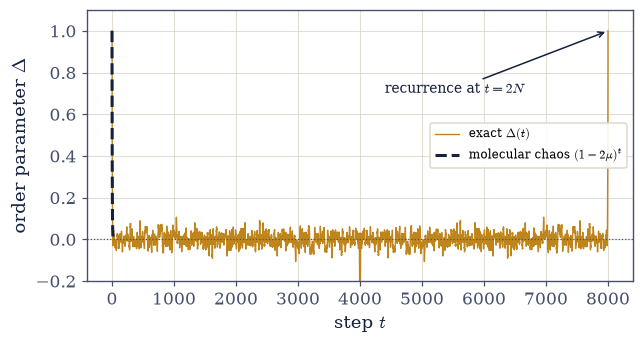

In [11]:
# (solution hidden on the public site)


## Exercise 4 — The H-theorem and the Stoßzahlansatz (worked)

With the Kac ring's lesson in hand, we name the real thing it models. Boltzmann's kinetic equation
describes how a gas's velocity distribution $f(\mathbf v,t)$ evolves under collisions, and its
crucial input is the **Stoßzahlansatz** — the molecular-chaos assumption that two particles about to
collide are *uncorrelated*, exactly the assumption that made the markers "random" in the Kac ring.
That assumption, and not the underlying reversible mechanics, is what breaks time-reversal symmetry,
and from it Boltzmann proved his **H-theorem**: the functional $H=\int f\ln f\,d\mathbf v$ decreases
monotonically (so the entropy $-kH$ increases) until $f$ reaches the unique stationary distribution
{eq}`eq-htheorem`. That stationary distribution is **Maxwell–Boltzmann** — and we can see *why* it is
special directly: among all velocity distributions with a fixed energy, Maxwell–Boltzmann is the one
that *minimizes* $H$ (equivalently, maximizes entropy), so any other same-energy distribution sits
higher and the H-theorem drives the gas downhill to it. The full collision integral and the Boltzmann
transport equation that surrounds it are a horizon we name but do not derive.

Reading $H$ off a finite sample is a measurement, and the Setup's `H_functional` is the meter:
it bins the speeds on a fixed grid, normalizes to a density $f$, and sums
$f_i\ln f_i\,\Delta v$ over the occupied bins — the discretized $\int f\ln f\,dv$, with empty
bins left out because $f\ln f\to0$ there. The grid is the same ($30$ bins over
$0\le v\le3.5$) for everything measured in this notebook, since a comparison made on two
different grids would measure the binning instead of the physics. The three test distributions
each carry $40\,000$ two-dimensional velocities at the same mean kinetic energy
$\langle v^2\rangle=1$: Maxwell–Boltzmann with $kT/m=0.5$ (each component a Gaussian of
variance $kT/m$), a set with every particle at the same speed $v_{\rm rms}$ in a random
direction, and a two-speed mixture ($v_{\rm rms}/2$ and $\sqrt{1.5}\,v_{\rm rms}$, half the
particles each).

**Part a)** Build those three equal-energy samples with `numpy.random.default_rng`.

**Part b)** Compute $H$ for each and confirm Maxwell–Boltzmann has the lowest — the equilibrium
the H-theorem drives toward.

In [12]:
# (solution hidden on the public site)


H = ∫ f ln f for three distributions at the same energy ⟨v²⟩ = 1:
  Maxwell–Boltzmann : H = -0.597   ← the minimum (maximum entropy)
  all equal speed   : H = +2.148
  two speeds        : H = +1.455


### Validation 4

In [13]:
validate.check(
    H_mb < H_equal and H_mb < H_bimodal,
    "the Maxwell–Boltzmann distribution has lower H than the tested non-equilibrium distributions — the equilibrium the H-theorem drives toward",
)

✓  the Maxwell–Boltzmann distribution has lower H than the tested non-equilibrium distributions — the equilibrium the H-theorem drives toward


True

## Exercise 5 — A gas relaxes to Maxwell–Boltzmann (worked)

Now we watch the H-theorem happen. We model a gas by a caricature of the Boltzmann collision process:
repeated **random binary collisions** that conserve momentum and energy, each one rotating a
colliding pair's relative velocity by a random angle. This is molecular chaos
made literal — every collision scrambles the participants' correlations — and it is exactly the
ingredient that makes the dynamics irreversible. We start the gas in a sharply non-equilibrium state,
all particles moving at the *same* speed in random directions, and let the collisions run. The speed
distribution flows, irreversibly, to the two-dimensional **Maxwell–Boltzmann** law $f(v)\propto v\,
e^{-mv^2/2kT}$ of [§5.6](ideal-gas-fundamental-relation.ipynb) {eq}`eq-relaxation`, and Boltzmann's $H=\int f\ln f$ falls monotonically the
whole way ({numref}`fig-ne-relaxation`). Energy and momentum are conserved at every step, so nothing
is driving the gas but the statistics of collisions — and yet it has a clear, one-directional
destination. The equilibrium it finds is precisely the Boltzmann distribution the rest of the volume
computed from the ensembles; the dynamics and the ensembles agree.

One collision is pure bookkeeping in the centre-of-mass frame. For a pair $(i,j)$ write
$\mathbf v_{\rm cm}=\tfrac12(\mathbf v_i+\mathbf v_j)$ and
$\mathbf v_{\rm rel}=\mathbf v_i-\mathbf v_j$; rotating $\mathbf v_{\rm rel}$ by an angle
$\theta$ and putting the pair back as
$\mathbf v_{i,j}=\mathbf v_{\rm cm}\pm\tfrac12\mathbf v_{\rm rel}$ leaves the total momentum
(through $\mathbf v_{\rm cm}$) and the total kinetic energy (through $|\mathbf v_{\rm rel}|$)
untouched, so nothing but the *direction* information is scrambled — which is exactly what
molecular chaos asserts. The gas below is $15\,000$ particles started at the single speed
$v_0=1$ in random directions, relaxed in $50$ rounds of $3000$ collisions each, with $H$ and a
snapshot of the speeds recorded after every round. In two dimensions the equilibrium it should
find has $\langle v^2\rangle=2kT/m$, mean speed $\sqrt{\pi kT/2m}$ and
$v_{\rm rms}=\sqrt{2kT/m}$.

**Part a)** Write `random_collisions(v, n_collisions, rng)`, applying that many random binary
collisions to a velocity array of shape `(n, 2)` in place and returning it.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Relax the gas from its all-equal-speed start, recording $H$ (with the Setup's
`H_functional`, on the same grid Exercise 4 used) and the speed distribution after each round
of collisions.

**Part c)** Confirm the final mean and rms speeds match the 2-D Maxwell–Boltzmann values
(`rtol=2e-2`), that $H$ fell monotonically, and that the kinetic energy was conserved
throughout. The animation shows the distribution morphing to Maxwell–Boltzmann.

In [14]:
# (solution hidden on the public site)


gas relaxation by energy-conserving collisions (n = 15000):
  H decreased: +2.148 → -0.604  (monotone: True)
  kinetic energy conserved: True
  ⟨|v|⟩ = 0.8844 vs MB √(πkT/2m) = 0.8862;  v_rms = 1.0000 vs √(2kT/m) = 1.0000


### Validation 5

In [15]:
validate.close(
    [speeds_final.mean(), np.sqrt((speeds_final**2).mean())],
    [np.sqrt(np.pi * kT_m / 2), np.sqrt(2 * kT_m)],
    "energy-conserving collisions relax the gas to the 2-D Maxwell–Boltzmann distribution (5.6)",
    rtol=2e-2,
)
validate.check(
    np.all(np.diff(H_history) < 0.01) and H_history[-1] < H_history[0] - 1,
    "H = ∫ f ln f decreases monotonically as the gas relaxes — the H-theorem in action",
)

✓  energy-conserving collisions relax the gas to the 2-D Maxwell–Boltzmann distribution (5.6)   [max|Δ| = 0.00179839 (rtol=0.02, atol=1e-09)]
✓  H = ∫ f ln f decreases monotonically as the gas relaxes — the H-theorem in action


True

In [16]:
# (solution hidden on the public site)


## Exercise 6 — The resolution: irreversibility as overwhelming probability (worked)

We can now state the resolution plainly, because every piece is in place. Irreversibility does not
contradict the reversibility of the microscopic laws; it emerges from **coarse-graining** plus
**overwhelming probability**, and the overwhelming probability is the same $1/\sqrt N$ concentration
that has run through the whole volume {eq}`eq-resolution`. The equilibrium macrostate corresponds to
so vastly many more microstates than any non-equilibrium one ([§5.3](large-n-limit.ipynb), [§5.4](microstates-entropy-temperature.ipynb)) that it occupies essentially
*all* of phase space; a system started in a rare, ordered corner therefore moves, with overwhelming
probability, toward equilibrium — not because it is forced to, but because almost every path leads
there. The reversed, entropy-*decreasing* trajectories that Loschmidt invoked genuinely exist, but
they are a vanishing fraction, and the Poincaré recurrences that Zermelo invoked are real but occur
on timescales of order $e^{N}$. Put a number on it: for a macroscopic gas of $N\sim10^{23}$
particles the recurrence time exceeds the age of the universe not by a large factor but by a factor
of order $10^{(10^{23})}$ — a number whose *exponent* dwarfs every quantity in cosmology. The arrow
of time is not a new law layered onto mechanics; it is the statistics of large numbers applied to
dynamics, the same sharpness that made macrostates definite in [§5.3](large-n-limit.ipynb) now making time's direction
effectively absolute.

The estimate needs only three numbers and one exponent. A macroscopic sample holds
$N\approx6\times10^{23}$ particles, its microscopic clock is a collision time of about
$10^{-13}\,$s, and the universe is some $4.4\times10^{17}\,$s old. Poincaré recurrence takes of
order $e^{N}$ microscopic times, so the ratio of the recurrence time to the age of the universe
is best handled in logarithms: $\log_{10}=N/\ln10-\log_{10}(t_{\rm universe}/t_{\rm micro})$,
where the second term — about $30$ — is utterly swamped by the first.

**Part a)** Form that $\log_{10}$ of the recurrence time in units of the age of the universe.

**Part b)** Confirm it exceeds $10^{20}$: recurrence and reversal are real but utterly
negligible, so the arrow of time is effectively absolute.

In [17]:
# (solution hidden on the public site)


the resolution: equilibrium is overwhelmingly probable; recurrence is real but negligible
  Poincaré recurrence time / age of universe ≈ 10^(2.61e+23)
  i.e. the recurrence time is ~10^(10^23) times the age of the universe — utterly unobservable
  reversed (entropy-decreasing) paths exist but are a vanishing fraction ~e^(−O(N)) of all paths


### Validation 6

In [18]:
validate.check(
    log10_recurrence_over_age > 1e20,
    "equilibrium is overwhelmingly probable and the recurrence time is astronomical (~e^N) — reversal and recurrence are real but negligible, so the arrow of time is effectively absolute",
)

✓  equilibrium is overwhelmingly probable and the recurrence time is astronomical (~e^N) — reversal and recurrence are real but negligible, so the arrow of time is effectively absolute


True

## Exercise 7 — Brownian motion and the Einstein relation (worked)

Having understood *why* systems relax, we turn to *how fast* — transport — and take our first honest
taste of it through the phenomenon that founded the subject. A pollen grain in water jitters
ceaselessly, kicked by the molecules it cannot see; Einstein (1905) and Langevin (1908) modelled
this as a heavy particle obeying $m\,\dot v=-\gamma v+\xi(t)$, where the same molecular collisions
appear *twice* — as a systematic **friction** $-\gamma v$ and as a randomly fluctuating **force**
$\xi$ with $\langle\xi(t)\xi(t')\rangle=2\gamma kT\,\delta(t-t')$ {eq}`eq-transport`. That the
friction coefficient and the noise strength are locked together by the same $\gamma kT$ is the first
**fluctuation–dissipation relation**: dissipation (friction) and fluctuation (noise) are two faces of
one molecular reality. Its most famous consequence is that free Brownian motion **diffuses**,
$\langle x^2\rangle=2Dt$, with the **Einstein relation** $D=kT/\gamma$ ({numref}`fig-ne-brownian`) —
the diffusion constant (a fluctuation) fixed by the friction (a dissipation), the dynamical extension
of the static response = fluctuation of [§5.9](grand-canonical-ensemble-equivalence.ipynb). We integrate the Langevin equation with the BAOAB scheme,
whose accuracy we will need in the next exercise.

BAOAB is a *splitting*: the Langevin equation is broken into three pieces that can each be
advanced exactly or symmetrically, and one timestep applies them in the palindromic order
B–A–O–A–B. **B** is half a force kick, $v\to v+\tfrac12\Delta t\,F(x)/m$ with
$F=-k_{\rm spring}x$ (zero for a free particle); **A** is half a drift,
$x\to x+\tfrac12\Delta t\,v$; and **O** is the Ornstein–Uhlenbeck thermostat, applied *exactly*
rather than by a Taylor step, $v\to cv+\sqrt{(1-c^2)kT/m}\;\mathcal N(0,1)$ with
$c=e^{-\gamma\Delta t/m}$ — friction and noise entering together, in the ratio the
fluctuation–dissipation relation fixes. The palindrome is what makes the scheme accurate on the
configurational side, and the exact **O** step is what makes it sample $\langle v^2\rangle=kT/m$
correctly; a naive Euler–Maruyama integrator biases that variance and would inflate the
Green–Kubo integral of Exercise 8, so the choice is not cosmetic. The run below is $8000$
independent free particles ($k_{\rm spring}=0$) for $1500$ steps of $\Delta t=0.02$ at
$m=\gamma=kT=1$, all released from $x_0=0$ with velocities drawn from the Maxwell–Boltzmann
$\sqrt{kT/m}\,\mathcal N(0,1)$. The mean-square displacement is diffusive only after the
ballistic transient, so the slope is fit on $t>5$ alone.

**Part a)** Write `langevin_baoab(n_part, n_steps, dt, m, gamma, kT, rng, k_spring=0.0, x0=0.0,
v_init=None)`, returning the position and velocity histories `(X, V)`, each of shape
`(n_steps + 1, n_part)`. **Write this one yourself** — the implementation is the lesson.

**Part b)** Simulate the free Brownian ensemble with it and form the mean-square displacement
$\langle x^2\rangle(t)$ over the particles.

**Part c)** Fit the diffusive slope on the late-time window, halve it to get $D$, and confirm
the Einstein relation $D=kT/\gamma$ (`rtol=8e-2`).

In [19]:
# (solution hidden on the public site)


free Brownian motion (m = γ = kT = 1, dt = 0.02):
  diffusion from ⟨x²⟩ = 2Dt:  D = 1.0089
  Einstein relation D = kT/γ: D = 1.0000
  diffusion (a fluctuation) is fixed by friction (a dissipation) — fluctuation–dissipation


### Validation 7

In [20]:
validate.close(
    D_msd,
    D_einstein,
    "free Brownian motion gives ⟨x²⟩ = 2Dt with the Einstein relation D = kT/γ (a fluctuation–dissipation relation)",
    rtol=8e-2,
)

✓  free Brownian motion gives ⟨x²⟩ = 2Dt with the Einstein relation D = kT/γ (a fluctuation–dissipation relation)   [got 1.00892 vs expected 1 (rtol=0.08, atol=1e-09)]


True

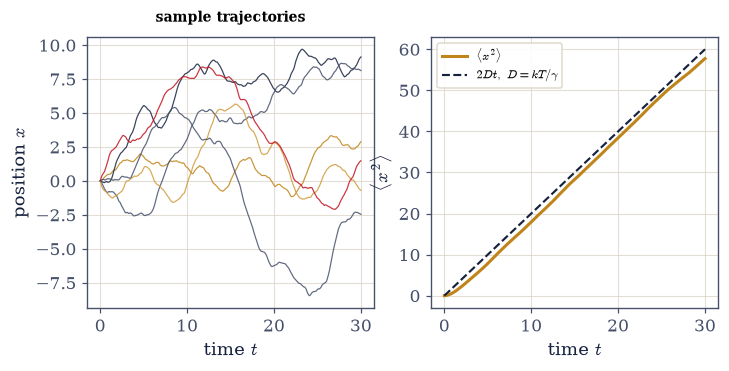

In [21]:
# (solution hidden on the public site)


## Exercise 8 — Autocorrelation functions and Green–Kubo (worked)

We close the transport taste with the idea that is the modern language of the whole subject, and we
build the one new tool it needs from scratch, here where it is used. The tool is the
**autocorrelation function** $C(t)=\langle A(0)A(t)\rangle$: it measures how long a fluctuating
quantity *remembers itself*, starting at the variance $\langle A^2\rangle$ at $t=0$ and decaying over
a characteristic correlation time as the memory is lost. For the Brownian particle's velocity, the
**velocity autocorrelation function** is $C(t)=\langle v(0)v(t)\rangle=(kT/m)\,e^{-(\gamma/m)t}$, a
clean exponential decaying over the time $m/\gamma$ {eq}`eq-transport`. The remarkable **Green–Kubo**
relation then expresses the transport coefficient as the *time integral* of this equilibrium
correlation, $D=\int_0^\infty\langle v(0)v(t)\rangle\,dt=kT/\gamma$ ({numref}`fig-ne-vacf`) — the same
$D$ we got from the mean-square displacement and from Einstein, now as an integral over how the
velocity forgets itself. This is the deep, general statement: a transport coefficient *is* an
equilibrium time-correlation function, the **dynamical** fluctuation–dissipation theorem. One numerical
caution, which we honour: we first verify the integrator gives $\langle v^2\rangle=kT/m$ (an
inaccurate scheme biases this and inflates the integral), then integrate the autocorrelation with
`numpy.trapezoid`, truncating after a few correlation times.

Estimating $C(t)$ from a finite record is an averaging question. A single pair $v(0)v(t)$ is
almost pure noise, so one averages over the particles — the columns of the velocity history —
*and* over many time origins, since in equilibrium every instant is as good a $t=0$ as any
other. With a record of $n$ rows and `n_lag` lags wanted, the clean choice is to use the first
$n-\texttt{n\_lag}$ rows as origins and, for each lag $t$, average the elementwise product of
that block with the block shifted forward by $t$. The trajectories are the Exercise 7 ones, so
the same $m=\gamma=kT=1$ and $\Delta t=0.02$ apply; $350$ lags reach about seven correlation
times $m/\gamma$, far enough out that the truncated integral has already flattened, and the
first $500$ steps are dropped from the variance check so the ensemble is thermalized.

**Part a)** Verify $\langle v^2\rangle=kT/m$ for the BAOAB trajectories of Exercise 7
(`rtol=2e-2`) — this comes first, because an inaccurate integrator would quietly inflate
everything after it.

**Part b)** Write `vacf(V, n_lag)`, returning $C(t)=\langle v(0)v(t)\rangle$ for lags
$0,1,\dots,\texttt{n\_lag}-1$ in timestep units. **Write this one yourself** — the
implementation is the lesson.

**Part c)** Confirm $C$ decays as $(kT/m)e^{-(\gamma/m)t}$ from $C(0)=kT/m$, and integrate it
with `numpy.trapezoid` to recover the Green–Kubo $D=kT/\gamma$ (`rtol=5e-2`) — the same $D$ the
mean-square displacement gave.

In [22]:
# (solution hidden on the public site)


integrator check: ⟨v²⟩ = 0.9988 vs kT/m = 1.0000  (must hold before trusting Green–Kubo)


velocity autocorrelation C(t) = ⟨v(0)v(t)⟩:
  C(0) = 0.9998 vs kT/m = 1.0000;  decay matches (kT/m)e^(−γt/m) to max |Δ| = 0.0020
  Green–Kubo D = ∫₀^∞ C(t) dt = 0.9999  vs  kT/γ = 1.0000  (agrees with the MSD/Einstein D)
  a transport coefficient IS an equilibrium time-correlation — the dynamical fluctuation–dissipation theorem


### Validation 8

In [23]:
validate.close(
    v2_mean,
    kT / m,
    "the BAOAB integrator gives ⟨v²⟩ = kT/m (verified before trusting the Green–Kubo integral)",
    rtol=2e-2,
)
validate.close(
    [C[0], D_greenkubo],
    [kT / m, kT / gamma],
    "the velocity autocorrelation integrates (Green–Kubo) to the diffusion coefficient D = kT/γ",
    rtol=5e-2,
)

✓  the BAOAB integrator gives ⟨v²⟩ = kT/m (verified before trusting the Green–Kubo integral)   [got 0.998755 vs expected 1 (rtol=0.02, atol=1e-09)]
✓  the velocity autocorrelation integrates (Green–Kubo) to the diffusion coefficient D = kT/γ   [max|Δ| = 0.000245462 (rtol=0.05, atol=1e-09)]


True

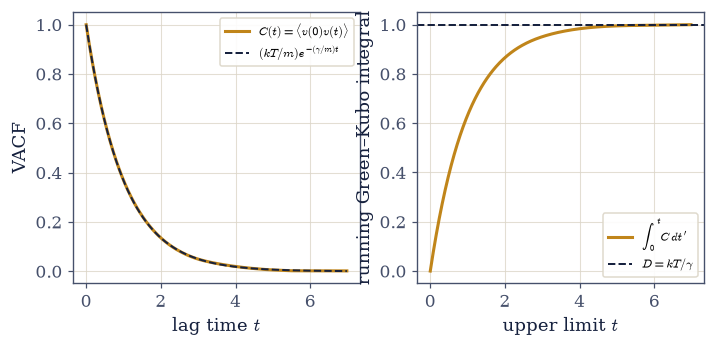

In [24]:
# (solution hidden on the public site)


## Exercise 9 — The Langevin dynamics relaxes to the Boltzmann equilibrium (student)

Before the synthesis, we close the loop the whole volume has drawn — explicitly, with the dynamics
flowing into the ensembles. Put a Brownian particle not in free space but in a harmonic trap, $U(x)=
\tfrac12 k x^2$, and start it far from the bottom. The Langevin dynamics — the same friction and
noise — now does two things at once: the friction drains its excess energy and the noise keeps it
warm, and the competition settles into a stationary distribution. That distribution is exactly the
**Boltzmann** one, $P(x)\propto e^{-kx^2/2kT}$, with $\langle x^2\rangle=kT/k$ — equipartition, the
very result the canonical ensemble of [§5.8](partition-function.ipynb) gave for a harmonic degree of freedom. So the
non-equilibrium dynamics does not merely *resemble* the equilibrium theory; it *flows into* it. The
arrow of time we have been chasing points precisely at the equilibrium distributions the rest of the
volume built, and the two descriptions — the dynamics that takes a system there, and the ensemble
that describes it once arrived — are one consistent whole.

The trap has stiffness $k=2$ and the particle starts at rest at $x_0=3$, far outside the
thermal width $\sqrt{kT/k}\approx0.7$ it must settle into, so the relaxation is visible rather
than assumed; $10\,000$ independent particles are run for $2500$ steps at the same
$m=\gamma=kT=1$ and $\Delta t=0.02$ as before. The equilibrium average is taken only after step
$1200$, by which time the transient has decayed and what is left is the stationary state.

**Part a)** Release the trapped ensemble with the `langevin_baoab` you wrote in Exercise 7,
passing the spring constant, the off-centre start and a zero initial velocity.

**Part b)** Measure $\langle x^2\rangle$ over the post-transient part of the run and confirm it
equals the Boltzmann/equipartition value $kT/k$ (`rtol=1e-1`) — the ensembles' answer, reached
by the dynamics.

In [25]:
# (solution hidden on the public site)


trapped Langevin particle (spring k = 2.0, released from x₀ = 3):
  equilibrium ⟨x²⟩ = 0.4996  vs  Boltzmann/equipartition kT/k = 0.5000
  the non-equilibrium dynamics flows into the Boltzmann equilibrium of the ensembles (5.4/5.8)


### Validation 9

In [26]:
validate.close(
    x2_equilibrium,
    kT / k_trap,
    "the trapped Langevin particle relaxes to the Boltzmann equilibrium ⟨x²⟩ = kT/k (equipartition) — the dynamics flows into the ensembles",
    rtol=1e-1,
)

✓  the trapped Langevin particle relaxes to the Boltzmann equilibrium ⟨x²⟩ = kT/k (equipartition) — the dynamics flows into the ensembles   [got 0.499593 vs expected 0.5 (rtol=0.1, atol=1e-09)]


True

## Exercise 10 — A glimpse through the door, and the close of the volume (synthesis)

We have opened the door just wide enough to see that the room behind it is enormous. The equilibrium
theory of this volume described where systems rest; this notebook asked how they get there, and found
that irreversibility and the arrow of time are not extra laws but *emergent* facts — they appear,
probabilistically, the moment one coarse-grains and counts. The **Kac ring** made it exact: a
reversible, recurrent toy whose coarse-grained order parameter nonetheless relaxes, answering
Loschmidt and Zermelo in one model. A **gas finding Maxwell–Boltzmann** made it physical, the
H-theorem driving a non-equilibrium distribution downhill to the very equilibrium the ensembles
compute. The **resolution** named the mechanism: equilibrium is overwhelmingly probable (the
$1/\sqrt N$ of [§5.3](large-n-limit.ipynb) once more), recurrences and reversals real but astronomically rare. And **Brownian
motion, the Einstein relation, and Green–Kubo** gave a first taste of transport — diffusion and
friction as one molecular reality, a transport coefficient revealed as an equilibrium time-correlation,
the dynamical fluctuation–dissipation theorem extending the static one of [§5.9](grand-canonical-ensemble-equivalence.ipynb) — with the trapped
particle flowing back into the Boltzmann equilibrium and closing the loop.

And then the honest horizons, named not crossed: the full Boltzmann transport equation and kinetic
theory; the Green–Kubo relations for viscosity and conductivity; **Onsager** reciprocity; **linear
response** and the fluctuation–dissipation theorem in full; the **Fokker–Planck** and master
equations; hydrodynamics; and the modern **fluctuation theorems** of Jarzynski and Crooks, which tie
non-equilibrium work to equilibrium free energy. Each is a doorway of its own, and
non-equilibrium statistical mechanics is a subject of its own. This was a taste.

There is no new computation here: the closing is the result. With it the **volume
closes**. We began at counting — how many microstates realize a macrostate ([§5.1](counting.ipynb)) — and built, from
probability alone, the entropy, the temperature, the ensembles, the structure of thermodynamics, the
emergence of order, and now the arrow of time. The arrow that felt like a fundamental law turned out
to be a *count*: the same statistics of large numbers that opened the volume, now pointing the
direction of time itself.

## Notebook summary

This final notebook of Volume V took a single honest taste of non-equilibrium statistical mechanics,
following irreversibility from reversible microscopic laws and closing the volume.

- **The puzzle** {eq}`eq-puzzle`: the microscopic dynamics is time-reversible (a Verlet trajectory
  retraces under velocity reversal) and recurrent, yet macroscopic systems relax irreversibly.
- **The Kac ring** {eq}`eq-kac`: a reversible, periodic toy whose order parameter relaxes as
  $(1-2\mu)^t$ under molecular chaos (verified) yet **recurs exactly** at $t=2N$ (verified) —
  Loschmidt's reversal and Zermelo's recurrence answered: irreversibility is emergent and approximate.
- **The H-theorem** {eq}`eq-htheorem`, {eq}`eq-relaxation`: the Stoßzahlansatz (molecular chaos)
  breaks time-reversal symmetry; Maxwell–Boltzmann minimizes $H=\int f\ln f$, and a gas of
  energy-conserving collisions relaxes to it (verified, $H$ monotone) — the Boltzmann equilibrium
  of [§5.6](ideal-gas-fundamental-relation.ipynb).
- **The resolution** {eq}`eq-resolution`: irreversibility is coarse-graining + overwhelming
  probability (the $1/\sqrt N$ of [§5.3](large-n-limit.ipynb)); recurrence times $\sim e^N$ dwarf the age of the universe by
  $\sim10^{(10^{23})}$.
- **A taste of transport** {eq}`eq-transport`: free Brownian motion gives $\langle x^2\rangle=2Dt$
  with the Einstein $D=kT/\gamma$; the velocity autocorrelation $(kT/m)e^{-(\gamma/m)t}$ integrates
  (Green–Kubo) to the same $D$ — transport coefficients are equilibrium time-correlations, the
  dynamical fluctuation–dissipation theorem ([§5.9](grand-canonical-ensemble-equivalence.ipynb)). A trapped particle relaxes to $\langle x^2\rangle
  =kT/k$, the ensembles' equilibrium.

Volume V built equilibrium from probability and then watched equilibrium assemble itself; the arrow
of time, which felt like a law, turned out to be the count that began the volume.

## Outlook

- **Non-equilibrium statistical mechanics, a subject of its own.** The Boltzmann transport equation
  and kinetic theory; the Green–Kubo relations for viscosity and thermal conductivity; Onsager
  reciprocity; linear response and the full fluctuation–dissipation theorem; the Fokker–Planck and
  master equations; hydrodynamics; and the modern fluctuation theorems (Jarzynski, Crooks) — each a
  horizon, a possible course of its own.
- **Stochastic and molecular simulation.** The Langevin integrator here is a first step, and
  [§5.17](molecular-dynamics.ipynb) takes the deterministic one the rest of the way — periodic
  boundaries, a measured pressure, and honest error bars on a correlated trajectory.
  [§5.18](nucleation.ipynb) then watches a metastable state decay, but only where the driving is
  strong enough that it decays unaided. The production craft that reaches the genuinely rare —
  canonical thermostats, free-energy methods, umbrella and forward-flux sampling — still belongs
  to molecular-simulation courses and MMM, and both notebooks say where they stop.
- **Volume VII: the quantum arrow of time.** Quantum dynamics, the quantum Boltzmann equation, and
  decoherence — how irreversibility appears in quantum systems — once Volume VI builds the mechanics.
- **Cross-reference** [§5.5](ergodicity.ipynb) (Liouville, reversibility, ergodicity), [§5.6](ideal-gas-fundamental-relation.ipynb) (Maxwell–Boltzmann), [§5.3](large-n-limit.ipynb)
  ($1/\sqrt N$), [§5.4](microstates-entropy-temperature.ipynb) (the Boltzmann equilibrium), [§5.9](grand-canonical-ensemble-equivalence.ipynb) (the static fluctuation–response this extends).

In [27]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>